<a href="https://colab.research.google.com/github/Bgail-ranu/Data-science/blob/main/CAPSTONE_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Load & Inspect**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/insurance.csv')
df.head()

Mounted at /content/drive


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.shape

(1338, 7)

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


In [ ]:
df['children'].value_counts()

,count
children,
0,574
1,324
2,240
3,157
4,25
5,18


In [ ]:
df['smoker'].value_counts()

,count
smoker,
no,1064
yes,274


# **Data Visualization**

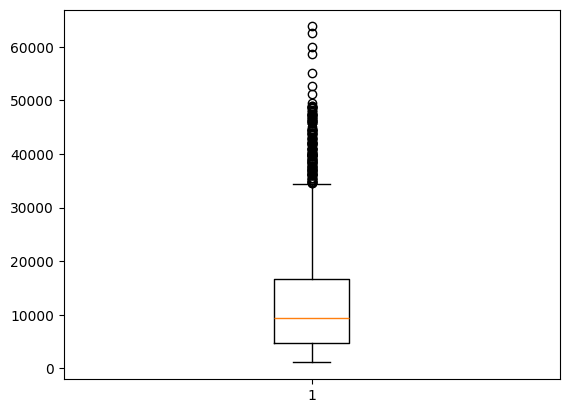

In [ ]:
plt.boxplot(df['charges'])
plt.show()

<Axes: title={'center': 'charges'}, xlabel='smoker'>

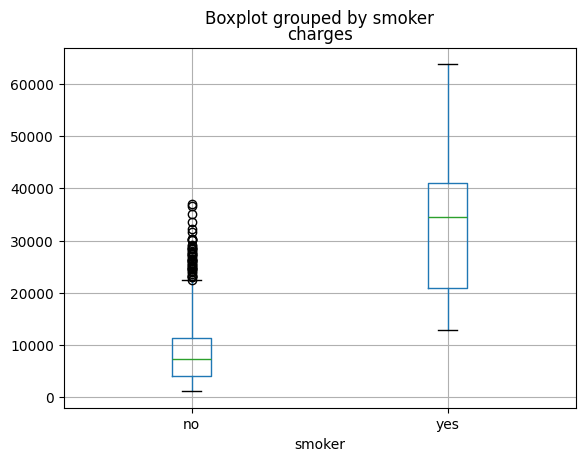

In [ ]:
df.boxplot(column='charges', by='smoker')


From the boxplots, it is obvious that the outliers in the charges are caused by SMOKERS.

1. Therefore, for my Regression, I will use log transformation to stabilize this variance in the charges.(charges_log)
2. For my Classification, I will maintain the actual value of charges. (charges)

# **Linear Regression Task**

## **Identify Target Variable & Features**

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [ ]:
df['charges_log'] = np.log(df['charges'])
y = df['charges_log']
x = df.drop(columns=['charges', 'charges_log'])

In [ ]:
df['charges']

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1333,10600.54830
1334,2205.98080
1335,1629.83350
1336,2007.94500


In [ ]:
df['charges_log']

,charges_log
0,9.734176
1,7.453302
2,8.400538
3,9.998092
4,8.260197
...,...
1333,9.268661
1334,7.698927
1335,7.396233
1336,7.604867


In [ ]:
x.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
dtypes: float64(1), int64(2), object(3)
memory usage: 62.8+ KB


## **Categorical and Numerical Features**

There are three numerical features and 3 categrorical features.
1. Numerical Features
- age
- bmi
- children

Use StandardScaler

2. Categorical Features
- sex
- smoker
- region

Use OneHotEncoder

In [ ]:
cat_features = x.select_dtypes(include=['object']).columns
num_features = x.select_dtypes(include=['int64', 'float64']).columns
cat_features, num_features

(Index(['sex', 'smoker', 'region'], dtype='object'),
 Index(['age', 'bmi', 'children'], dtype='object'))

## **Preprocessing & Encoding**

In [ ]:
scaler = StandardScaler()
encoder = OneHotEncoder(handle_unknown='ignore')
preprocessor = ColumnTransformer(
    transformers = [
        ('num', scaler, num_features),
        ('cat', encoder, cat_features)
    ]
)

## **Train-Test Split**

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((1070, 6), (268, 6), (1070,), (268,))

## **Build the Regression Model**

In [ ]:
lr = LinearRegression()
model = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('regressor', lr)
    ]
)
model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'bmi', 'children'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['sex', 'smoker', 'region'], dtype='object'))])),
                ('regressor', LinearRegression())])

## **Train Model**

In [ ]:
model.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'bmi', 'children'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['sex', 'smoker', 'region'], dtype='object'))])),
                ('regressor', LinearRegression())])

## **Make Predictions**

In [ ]:
y_pred = model.predict(x_test)

## **Model Evaluation**

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_absolute_error(y_test, y_pred))
mae, rmse

(0.26969163500404647, np.float64(0.5193184331448735))

In [ ]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
r2

0.8047311493462985

## **Feature Names**

In [ ]:
feature_name = model.named_steps['preprocessor'].get_feature_names_out()
coefficient = model.named_steps['regressor'].coef_
coef_df = pd.DataFrame({
    'Feature': feature_name,
    'Coefficient': coefficient
}).sort_values(by ='Coefficient', ascending = False)
coef_df.head(10)

,Feature,Coefficient
6,cat__smoker_yes,0.775849
0,num__age,0.481744
2,num__children,0.112363
1,num__bmi,0.082150
7,cat__region_northeast,0.078760
3,cat__sex_female,0.037175
8,cat__region_northwest,0.022346
4,cat__sex_male,-0.037175
10,cat__region_southwest,-0.043798
9,cat__region_southeast,-0.057308


# **Classification**

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'charges_log'],
      dtype='object')

In [ ]:
df['charges']

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1333,10600.54830
1334,2205.98080
1335,1629.83350
1336,2007.94500


Create a new column: 'high_payer'
payment greater than the median value are high pay(True)
Payment lower than the median value are low pay(False)

## **Feature Creation**

In [ ]:
df['high_payer'] = df['charges'] > df['charges'].median()
df['high_payer'].value_counts()

,count
high_payer,
True,669
False,669


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          1338 non-null   int64  
 1   sex          1338 non-null   object 
 2   bmi          1338 non-null   float64
 3   children     1338 non-null   int64  
 4   smoker       1338 non-null   object 
 5   region       1338 non-null   object 
 6   charges      1338 non-null   float64
 7   charges_log  1338 non-null   float64
 8   high_payer   1338 non-null   bool   
dtypes: bool(1), float64(3), int64(2), object(3)
memory usage: 85.1+ KB


In [ ]:
df['high_payer'].value_counts(normalize = True)

,proportion
high_payer,
True,0.5
False,0.5


## **Data Visualization**

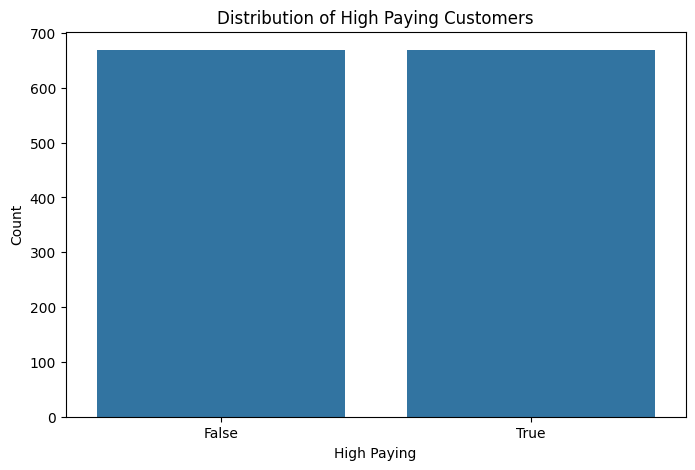

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='high_payer')
plt.title('Distribution of High Paying Customers')
plt.xlabel('High Paying')
plt.ylabel('Count')
plt.show()

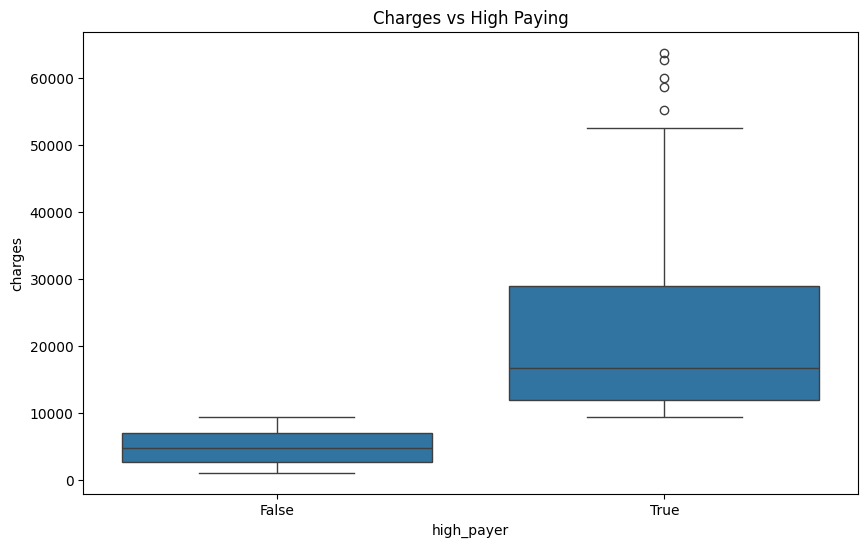

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='high_payer', y='charges')
plt.title('Charges vs High Paying')
plt.show()

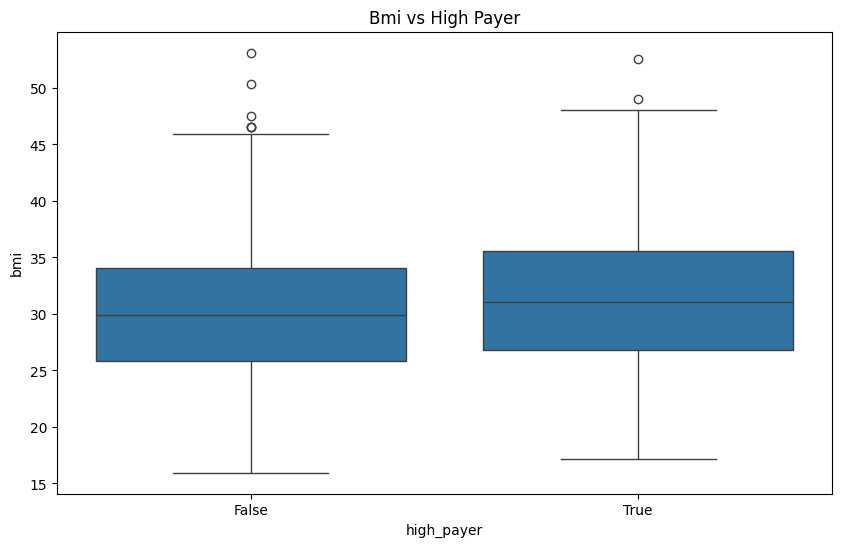

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='high_payer', y='bmi')
plt.title('Bmi vs High Payer')
plt.show()

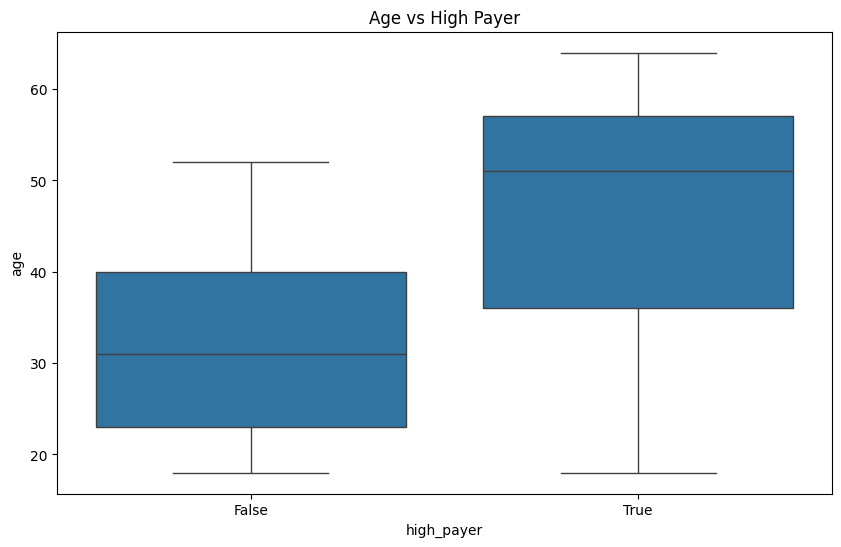

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='high_payer', y='age')
plt.title('Age vs High Payer')
plt.show()

In [ ]:
df.columns.to_list()

['age',
 'sex',
 'bmi',
 'children',
 'smoker',
 'region',
 'charges',
 'charges_log',
 'high_payer']

In [ ]:
print("\nCorrelation with High Paying Customers:")

df['high_payer_numeric'] = df['high_payer'].astype(int)
correlations = df[['charges', 'age', 'bmi']].corrwith(df['high_payer_numeric'])
print(correlations.sort_values(ascending=False))


Correlation with High Paying Customers:
charges    0.689856
age        0.512617
bmi        0.089896
dtype: float64


In [ ]:
df

,age,bmi,children,charges,charges_log,high_payer,high_payer_numeric,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,9.734176,True,1,False,True,False,False,True
1,18,33.770,1,1725.55230,7.453302,False,0,True,False,False,True,False
2,28,33.000,3,4449.46200,8.400538,False,0,True,False,False,True,False
3,33,22.705,0,21984.47061,9.998092,True,1,True,False,True,False,False
4,32,28.880,0,3866.85520,8.260197,False,0,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,9.268661,True,1,True,False,True,False,False
1334,18,31.920,0,2205.98080,7.698927,False,0,False,False,False,False,False
1335,18,36.850,0,1629.83350,7.396233,False,0,False,False,False,True,False
1336,21,25.800,0,2007.94500,7.604867,False,0,False,False,False,False,True


In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'charges_log', 'high_payer', 'high_payer_numeric'],
      dtype='object')

## **Separate X and Y**

In [ ]:
Y = df['high_payer'].astype(int)
x = df.drop(['high_payer', 'high_payer_numeric'], axis=1)

print(f"Features shape: {X.shape}")
print(f"Target shape: {Y.shape}")

Features shape: (1338, 10)
Target shape: (1338,)


In [ ]:
x

,age,bmi,children,charges,charges_log,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,9.734176,False,True,False,False,True
1,18,33.770,1,1725.55230,7.453302,True,False,False,True,False
2,28,33.000,3,4449.46200,8.400538,True,False,False,True,False
3,33,22.705,0,21984.47061,9.998092,True,False,True,False,False
4,32,28.880,0,3866.85520,8.260197,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,9.268661,True,False,True,False,False
1334,18,31.920,0,2205.98080,7.698927,False,False,False,False,False
1335,18,36.850,0,1629.83350,7.396233,False,False,False,True,False
1336,21,25.800,0,2007.94500,7.604867,False,False,False,False,True


## **Split Data**

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(x, Y, test_size=0.2, random_state=42, stratify=Y)
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (1070, 10)
Test set: (268, 10)


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.000000,27.000000,39.000000,51.000000,64.000000
bmi,1338.0,30.663397,6.098187,15.960000,26.296250,30.400000,34.693750,53.130000
children,1338.0,1.094918,1.205493,0.000000,0.000000,1.000000,2.000000,5.000000
charges,1338.0,13270.422265,12110.011237,1121.873900,4740.287150,9382.033000,16639.912515,63770.428010
charges_log,1338.0,9.098659,0.919527,7.022756,8.463853,9.146552,9.719558,11.063045
high_payer_numeric,1338.0,0.500000,0.500187,0.000000,0.000000,0.500000,1.000000,1.000000


## **Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Identify categorical columns
categorical_cols = X_train.select_dtypes(include='object').columns

# Apply Label Encoding to categorical columns
for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

In [ ]:
scaler = StandardScaler()

# Fit on training data (learn the mean and std)
# Transform both training and test data using those statistics
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")
print(f"Example - Before scaling: {X_train.iloc[0]['charges']}")
print(f"Example - After scaling: {X_train_scaled[0][0]:.2f}")

Features scaled successfully!
Example - Before scaling: 13143.86485
Example - After scaling: 1.55


In [ ]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, Y_train)
print('Logistic Regression trained')

y_pred_log = log_reg.predict(X_test_scaled)
print(classification_report(Y_test, y_pred_log))

Logistic Regression trained
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       134
           1       1.00      0.99      1.00       134

    accuracy                           1.00       268
   macro avg       1.00      1.00      1.00       268
weighted avg       1.00      1.00      1.00       268



## **New Data**

In [ ]:
new_data = pd.DataFrame({
    'age': [55],
    'bmi': [32.5],
    'children': [4],
    'sex': ['female'],
    'smoker': ['no'],
    'region': ['southeast']
})

In [ ]:
predicted_charges = model.predict(new_data)
print(predicted_charges)


[9.60550276]
